INFO:src.data.data_preprocessor:Starting complete preprocessing pipeline...


HCC RECURRENCE PREDICTION - MODEL TRAINING PHASE
 Loading and preprocessing data...


INFO:src.data.data_preprocessor:Loaded data with shape: (204, 50)
INFO:src.data.data_preprocessor:Original data shape: (204, 50)
INFO:src.data.data_preprocessor:After missing value handling: (204, 50)
INFO:src.data.data_preprocessor:Engineered features. Final shape: (204, 53)
INFO:src.data.data_preprocessor:After feature engineering: (204, 53)
INFO:src.data.data_preprocessor:Starting feature encoding and scaling...
INFO:src.data.data_preprocessor:Categorical features: 0
INFO:src.data.data_preprocessor:Numerical features: 52
INFO:src.data.data_preprocessor: Extracted feature names from pipeline: 52
INFO:src.data.data_preprocessor: Final feature count: 52
INFO:src.data.data_preprocessor: Processed data shape: (204, 52)
INFO:src.data.data_preprocessor:Training set: (163, 52)
INFO:src.data.data_preprocessor:Test set: (41, 52)
INFO:src.data.data_preprocessor:Class distribution - Train: {1: 82, 0: 81}
INFO:src.data.data_preprocessor:Class distribution - Test: {0: 21, 1: 20}
INFO:src.data.dat

 Data preprocessing completed!
 Training set: (163, 52)
 Test set: (41, 52)
 Class distribution - Train: {1: 82, 0: 81}
 Class distribution - Test: {0: 21, 1: 20}

 Initializing model trainer...

 Starting complete model training pipeline...


INFO:src.models.model_trainer:CV Random Forest: AUC = 0.8612 ± 0.0238
INFO:src.models.model_trainer:CV XGBoost: AUC = 0.8241 ± 0.0403
INFO:src.models.model_trainer:CV Logistic Regression: AUC = 0.8265 ± 0.0377
INFO:src.models.model_trainer:CV Gradient Boosting: AUC = 0.8715 ± 0.0163
INFO:src.models.model_trainer:CV SVM: AUC = 0.8961 ± 0.0292
INFO:src.models.model_trainer:Tuning Random Forest...
INFO:src.models.model_trainer:Best params for Random Forest: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
INFO:src.models.model_trainer:Best CV score: 0.8691
INFO:src.models.model_trainer:Tuning XGBoost...
INFO:src.models.model_trainer:Best params for XGBoost: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
INFO:src.models.model_trainer:Best CV score: 0.8713
INFO:src.models.model_trainer:Tuning Logistic Regression...
INFO:src.models.model_trainer:Best params for Logistic Regression: {'C': 0.1, 'penalty': 'l2', 'solver': 'saga'

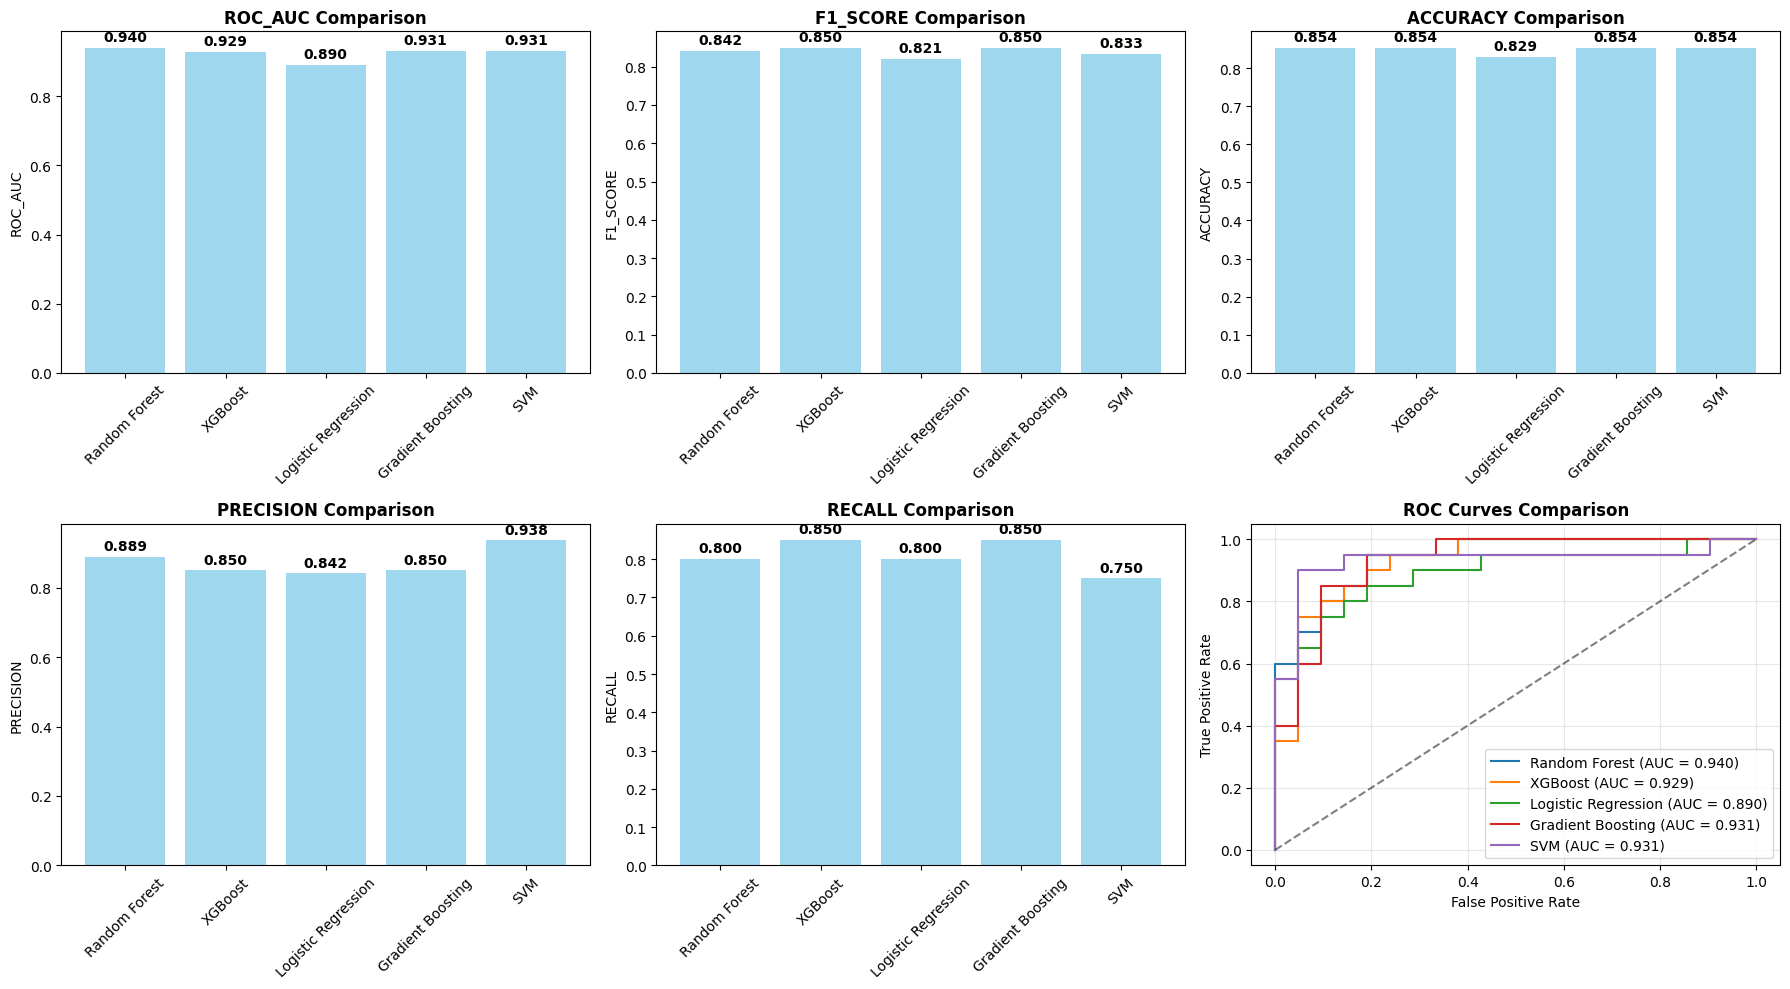

INFO:src.models.model_trainer: Models and results saved to ../models/trained_models/
INFO:src.models.model_trainer: Training pipeline completed successfully!



 COMPREHENSIVE MODEL PERFORMANCE RESULTS

Performance Metrics Comparison:
                     Accuracy  Precision  Recall  F1-Score  ROC AUC  PR AUC
Random Forest          0.8537     0.8889    0.80    0.8421   0.9405  0.9406
SVM                    0.8537     0.9375    0.75    0.8333   0.9310  0.9453
Gradient Boosting      0.8537     0.8500    0.85    0.8500   0.9310  0.9196
XGBoost                0.8537     0.8500    0.85    0.8500   0.9286  0.9174
Logistic Regression    0.8293     0.8421    0.80    0.8205   0.8905  0.9087

 BEST MODEL IDENTIFIED
Best Model: Random Forest
ROC AUC Score: 0.9405
F1-Score: 0.8421

 MODEL INTERPRETATION & FEATURE ANALYSIS
Generating model interpretation report...


INFO:src.models.model_evaluator:Interpretation report saved to ../reports/model_interpretation_report.png


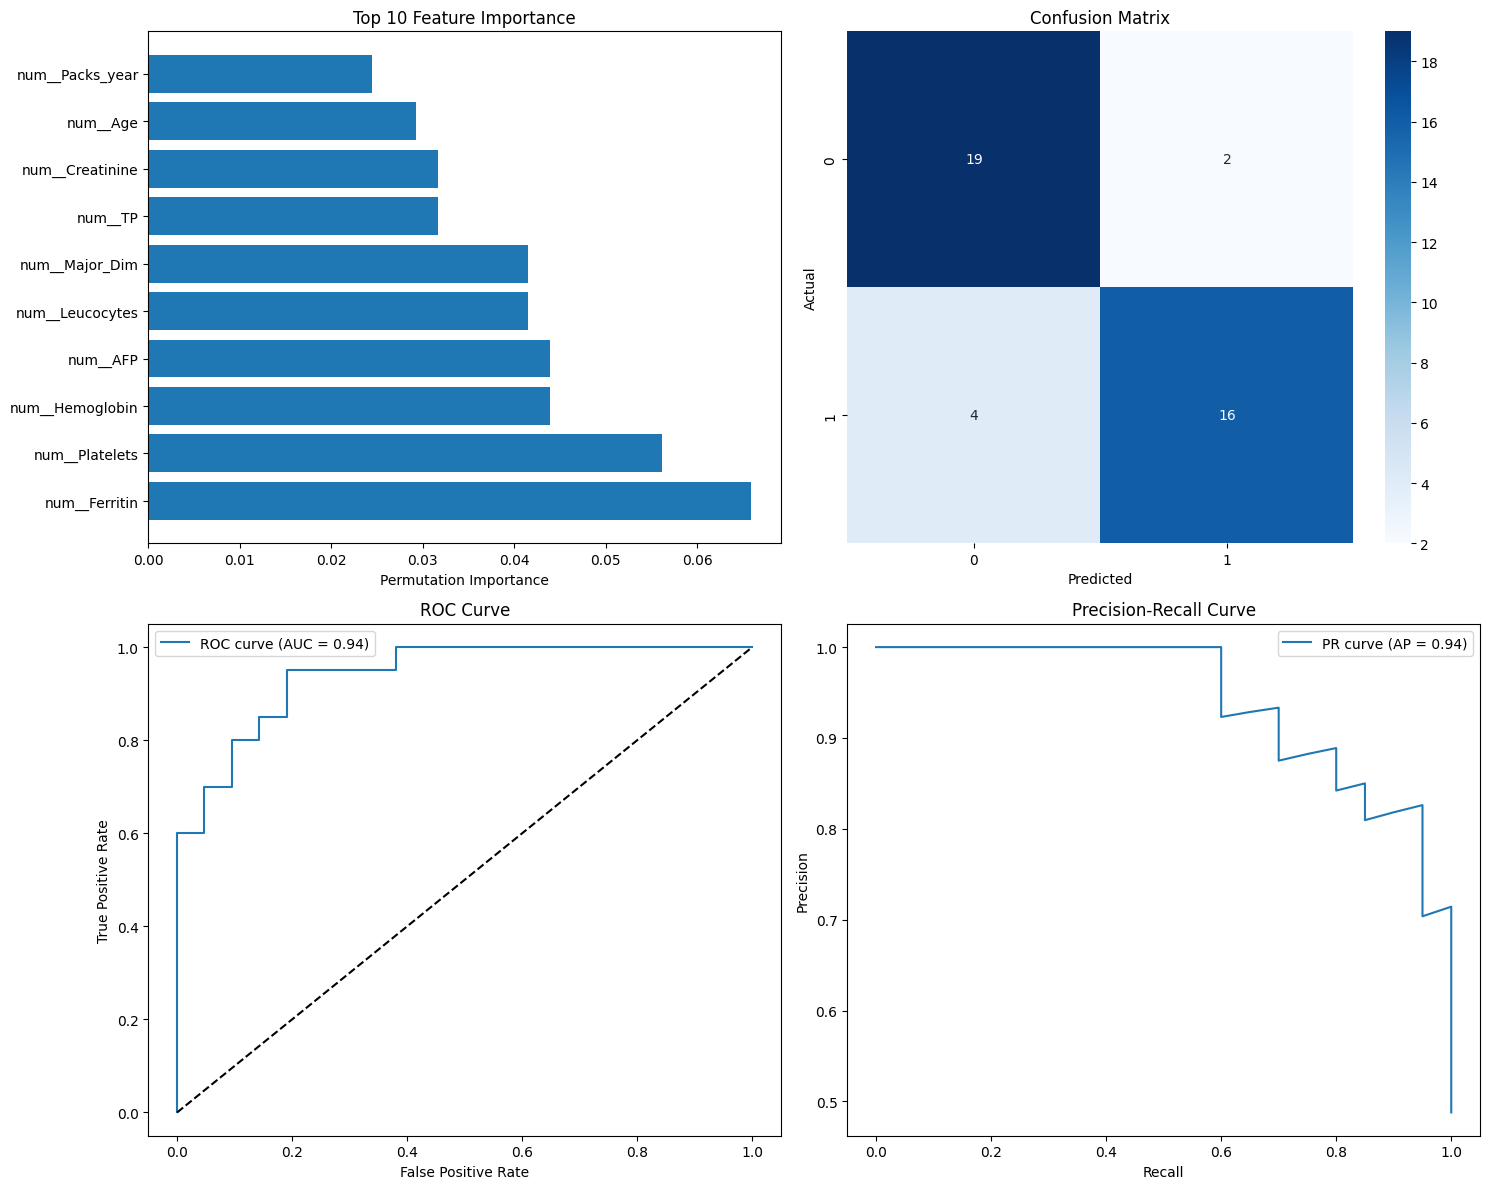


 Top 10 Most Important Features:
            feature  importance_mean  importance_std
48    num__Ferritin           0.0659          0.0309
34   num__Platelets           0.0561          0.0156
31  num__Hemoglobin           0.0439          0.0390
30         num__AFP           0.0439          0.0305
33  num__Leucocytes           0.0415          0.0156
44   num__Major_Dim           0.0415          0.0112
41          num__TP           0.0317          0.0112
42  num__Creatinine           0.0317          0.0156
23         num__Age           0.0293          0.0183
25  num__Packs_year           0.0244          0.0109

 CLINICAL INSIGHTS & RECOMMENDATIONS
Top 5 clinically significant features for recurrence prediction:
1. num__Ferritin
2. num__Platelets
3. num__Hemoglobin
4. num__AFP
5. num__Leucocytes

 MODEL DEPLOYMENT PREPARATION
 All models trained and evaluated successfully
 Best model selected and saved
 Model interpretation completed
 Performance metrics documented
 Ready for web applica

In [8]:
# %% [markdown]
"""
# HCC Recurrence Prediction - Model Training & Comparison
## Complete Implementation with All Algorithms
"""

# %%
import sys
import os
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Import custom modules
from src.data.data_preprocessor import HCCDataPreprocessor
from src.models.model_trainer import HCCModelTrainer
from src.models.model_evaluator import HCCModelInterpreter

# %%
print("=" * 80)
print("HCC RECURRENCE PREDICTION - MODEL TRAINING PHASE")
print("=" * 80)

# %%
# Load and preprocess data
print(" Loading and preprocessing data...")

preprocessor = HCCDataPreprocessor()
X_train, X_test, y_train, y_test, df_processed = preprocessor.full_preprocessing_pipeline(
    file_path='../data/raw/hcc-data-complete-balanced.xlsx',
    save_path='../models/preprocessing/'
)

print(f" Data preprocessing completed!")
print(f" Training set: {X_train.shape}")
print(f" Test set: {X_test.shape}")
print(f" Class distribution - Train: {y_train.value_counts().to_dict()}")
print(f" Class distribution - Test: {y_test.value_counts().to_dict()}")

# %%
# Initialize model trainer
print("\n Initializing model trainer...")
model_trainer = HCCModelTrainer()

# %%
# Execute complete training pipeline
print("\n Starting complete model training pipeline...")

# -----------------------------------------------------------------
#  FIX 1: Using keyword arguments
# -----------------------------------------------------------------
best_model_name, best_model = model_trainer.full_training_pipeline(
    X_train=X_train, 
    y_train=y_train, 
    X_test=X_test, 
    y_test=y_test,
    save_path='../models/trained_models/'
)
# -----------------------------------------------------------------

# %%
# Display comprehensive results
print("\n" + "=" * 60)
print(" COMPREHENSIVE MODEL PERFORMANCE RESULTS")
print("=" * 60)

performance_results = model_trainer.model_performance

# Create performance comparison table
performance_df = pd.DataFrame()

for model_name, metrics in performance_results.items():
    performance_df[model_name] = [
        metrics['accuracy'],
        metrics['precision'],
        metrics['recall'],
        metrics['f1_score'],
        metrics['roc_auc'],
        metrics['pr_auc']
    ]

performance_df.index = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC AUC', 'PR AUC']
performance_df = performance_df.T.round(4)

print("\nPerformance Metrics Comparison:")
print(performance_df.sort_values('ROC AUC', ascending=False))

# %%
# Best model details
print("\n" + "=" * 50)
print(" BEST MODEL IDENTIFIED")
print("=" * 50)
print(f"Best Model: {model_trainer.best_model_name}")
print(f"ROC AUC Score: {performance_results[model_trainer.best_model_name]['roc_auc']:.4f}")
print(f"F1-Score: {performance_results[model_trainer.best_model_name]['f1_score']:.4f}")

# %%
# Model Interpretation
print("\n" + "=" * 50)
print(" MODEL INTERPRETATION & FEATURE ANALYSIS")
print("=" * 50)

# Initialize interpreter
interpreter = HCCModelInterpreter(
    model=best_model,
    feature_names=preprocessor.feature_names,
    class_names=['No Recurrence', 'Recurrence']
)

# Generate comprehensive interpretation report
print("Generating model interpretation report...")
# -----------------------------------------------------------------
#  FIX 2 & 3: Removed .values and the extra 'y_train' argument
# -----------------------------------------------------------------
interpretation_fig = interpreter.generate_interpretation_report(
    X_train, X_test, y_test,
    save_path='../reports/model_interpretation_report.png'
)
# -----------------------------------------------------------------

# %%
# Feature Importance Analysis
print("\n Top 10 Most Important Features:")

# Get permutation importance
# -----------------------------------------------------------------
#  FIX 4: Removed .values from X_test
# -----------------------------------------------------------------
perm_importance = interpreter.get_feature_importance(X_test, y_test)
# -----------------------------------------------------------------
if perm_importance is not None:
    print(perm_importance.head(10).round(4))

# %%
# Clinical Insights
print("\n" + "=" * 50)
print(" CLINICAL INSIGHTS & RECOMMENDATIONS")
print("=" * 50)

if perm_importance is not None:
    top_features = perm_importance.head(5)['feature'].tolist()
    print("Top 5 clinically significant features for recurrence prediction:")
    for i, feature in enumerate(top_features, 1):
        print(f"{i}. {feature}")

# %%
# Model Deployment Preparation
print("\n" + "=" * 50)
print(" MODEL DEPLOYMENT PREPARATION")
print("=" * 50)

print(" All models trained and evaluated successfully")
print(" Best model selected and saved")
print(" Model interpretation completed")
print(" Performance metrics documented")
print(" Ready for web application integration")

# %%
# Final Summary
print("\n" + "=" * 80)
print("PHASE 2 COMPLETED: MODEL TRAINING & COMPARISON")
print("=" * 80)
print(" Key Achievements:")
print(f"• Trained and compared {len(model_trainer.models)} different algorithms")
print(f"• Best model: {model_trainer.best_model_name} with AUC: {performance_results[model_trainer.best_model_name]['roc_auc']:.4f}")
print(f"• Comprehensive model interpretation provided")
print(f"• All models saved for deployment")
print(" Next: Web Application Development & Deployment")